In [1]:
import pandas as pd
import xarray as xr
import os
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
# Electricity demand ASEAN 
path = r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data\ssp2-2.6\2030\era5_2018\Asia.csv"  # or Europe.nc etc.
countries = ["BN", "KH", "ID", "LA", "MY", "MM", "PH", "SG", "TH", "VN"]
# Load as pandas DataFrame since the file is CSV
ds = pd.read_csv(path,sep=';')

# If you want to filter by region_code using the countries list
ds_selected = ds[ds['region_code'].isin(countries)]

# Save the filtered DataFrame to CSV
ds_selected=ds_selected.set_index('time')
el_demand_asean=ds_selected.groupby('region_name').sum()['Electricity demand']
display(el_demand_asean) 
el_demand_asean.sum()/1e6 # Convert to TWh, asean 2050

region_name
Brunei         5.426202e+06
Cambodia       9.182338e+06
Indonesia      3.090736e+08
Laos           0.000000e+00
Malaysia       1.935340e+08
Myanmar        2.304582e+07
Philippines    1.132806e+08
Singapore      6.639179e+07
Thailand       2.757739e+08
Vietnam        2.112464e+08
Name: Electricity demand, dtype: float64

1206.9545497807856

In [3]:
# Renewable profiles
solar = xr.open_dataset(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\renewable_profiles\profile_solar.nc")
wind_on = xr.open_dataset(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\renewable_profiles\profile_onwind.nc")
wind_off_ac = xr.open_dataset(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\renewable_profiles\profile_offwind-ac.nc") 
wind_off_dc = xr.open_dataset(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\renewable_profiles\profile_offwind-dc.nc") 
wind = xr.Dataset({
    "onshore": wind_on["potential"],
    "offshore_ac": wind_off_ac["potential"],
    "offshore_dc": wind_off_dc["potential"]
})
wind["total_potential"] = wind.to_array(dim="source").sum(dim="source", skipna=True)
country_shape_data = gpd.read_file(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\shapes\country_shapes.geojson").set_index('name')
country_shape_data = country_shape_data.to_crs("EPSG:4326")

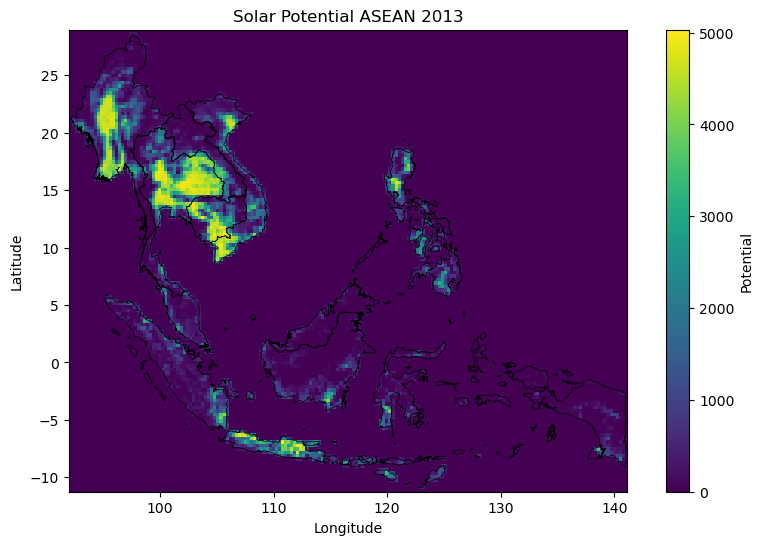

In [4]:

ds = solar  # already loaded
potential = ds['potential']
potential = potential.rio.write_crs("EPSG:4326")
# Plot
import numpy as np

# Get coordinate centers from xarray
x = ds['x'].values
y = ds['y'].values
z = ds['potential'].values

# Compute edges from centers
dx = (x[1] - x[0]) / 2
dy = (y[1] - y[0]) / 2
x_edges = np.concatenate([[x[0] - dx], x[:-1] + dx, [x[-1] + dx]])
y_edges = np.concatenate([[y[0] - dy], y[:-1] + dy, [y[-1] + dy]])

# Plot using imshow with correct extent
fig, ax = plt.subplots(figsize=(10, 6))
img = ax.imshow(
    z,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    cmap="viridis",
    aspect="auto"
)

# Overlay country borders
country_shape_data.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)

# Colorbar + labels
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Potential")
plt.title("Solar Potential ASEAN 2018")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



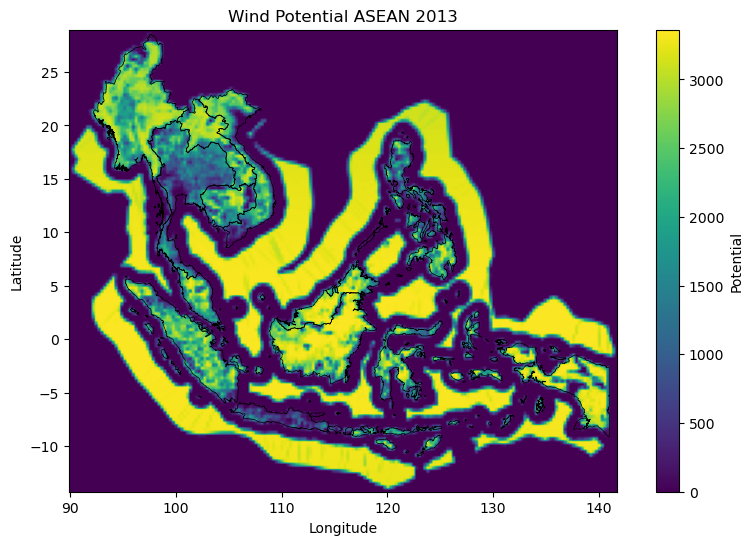

In [5]:

ds = wind  # already loaded
potential = ds  # ['potential']
potential = potential.rio.write_crs("EPSG:4326")
# Plot
import numpy as np

# Get coordinate centers from xarray
x = ds['x'].values
y = ds['y'].values

# Select one variable to plot, e.g., "onshore"
z = ds['total_potential'].values

# Compute edges from centers
dx = (x[1] - x[0]) / 2
dy = (y[1] - y[0]) / 2
x_edges = np.concatenate([[x[0] - dx], x[:-1] + dx, [x[-1] + dx]])
y_edges = np.concatenate([[y[0] - dy], y[:-1] + dy, [y[-1] + dy]])

# Plot using imshow with correct extent
fig, ax = plt.subplots(figsize=(10, 6))
img = ax.imshow(
    z,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    cmap="viridis",
    aspect="auto"
)

# Overlay country borders
country_shape_data.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)

# Colorbar + labels
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Potential")
plt.title("Wind Potential ASEAN 2018")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



In [6]:
# other energy  
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\energy_totals_base.csv",sep=',')
ds = ds[ds["Unnamed: 0.1"].isin(countries)]
display(ds)
ds.columns
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/demand/efficiency_gains_cagr.csv",sep=',')
display(ds)
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/demand/growth_factors_cagr.csv",sep=',')
display(ds)
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/demand/district_heating.csv",sep=',')
display(ds)
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/demand/fuel_shares.csv",sep=',')
display(ds)


,Unnamed: 0.1,Unnamed: 0,agriculture biomass,agriculture electricity,agriculture oil,electricity rail,electricity residential,residential biomass,residential gas,residential heat biomass,...,other electricity,other oil,other biomass,other gas,other heat,non energy electricity,non energy oil,non energy biomass,non energy gas,non energy heat
0,PH,NaN,0.0461,2.7900,2.8012,0.1062,30.5520,59.4536,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0380,9.9211,0.0,0.0000,0.0
1,TH,NaN,0.0000,0.4680,34.9603,0.2150,49.2020,31.4891,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,221.4579,0.0,53.7731,0.0
2,MM,NaN,0.0000,0.0000,16.0165,0.0000,8.0758,55.9500,0.0000,NaN,...,0.0000,0.3808,0.0,0.0000,0.0,0.0000,3.9765,0.0,1.9186,0.0
3,BN,NaN,NaN,NaN,NaN,NaN,1.3287,0.0296,0.2333,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,1.5273,0.0,6.0653,0.0
4,KH,NaN,0.0000,0.0000,0.0036,0.0000,3.3996,7.9612,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,0.1545,0.0,0.0000,0.0
5,VN,NaN,4.4005,6.5954,10.9716,NaN,85.2952,2.7928,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,7.7632,0.0,8.3039,0.0
6,MY,NaN,0.0000,0.6639,10.2298,0.4778,31.5702,5.7866,0.0078,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,32.8993,0.0,139.8046,0.0
7,SG,NaN,NaN,NaN,NaN,3.0193,7.6813,0.0000,0.7359,NaN,...,0.0000,0.0000,0.0,0.0415,0.0,0.0000,78.4750,0.0,0.0000,0.0
8,ID,NaN,0.0000,0.5940,4.3145,0.2780,104.7140,85.6952,0.2417,NaN,...,NaN,NaN,NaN,NaN,NaN,4.4999,26.2596,0.0,79.8011,0.0
9,LA,NaN,0.0000,0.0419,0.3821,NaN,2.1358,9.8660,0.0000,NaN,...,0.9722,0.0000,0.0,0.0000,0.0,0.0000,0.0212,0.0,0.0000,0.0


,Unnamed: 0,total residential space,total residential water,electricity residential,total services space,total services water,total rail,electricity rail,total domestic aviation,total international aviation,...,services biomass,services gas,total road ev,total road fcev,total road ice,total navigation oil,total navigation hydrogen,residential heat biomass,residential heat oil,residential heat gas
0,DEFAULT,-0.004951,-0.01039,-0.002696,-0.006705,-0.017864,-0.004951,-0.002146,0.0,0.0,...,-0.00553,0.0,-0.061401,-0.026527,0.0,-0.001063,-0.008517,-0.002696,-0.002696,0.0
1,MA,-0.004951,-0.01039,-0.002696,-0.006705,-0.017864,-0.004951,-0.002146,0.0,0.0,...,-0.00553,0.0,-0.061401,-0.026527,0.0,-0.001063,-0.008517,-0.002696,-0.002696,0.0
2,TN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN
3,US,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0


,Unnamed: 0,total residential space,total residential water,electricity residential,total services space,total services water,total road,total rail,electricity rail,total domestic aviation,...,residential oil,residential biomass,residential gas,agriculture biomass,services oil,services biomass,services gas,residential heat oil,residential heat biomass,residential heat gas
0,DEFAULT,0.02157,0.025046,0.055686,0.017867,0.02157,0.013904,0.049408,0.039822,0.037155,...,0.000,0.0000,0.010955,0.014719,-0.035824,0.0,-0.006115,0.000,0.0000,0.0000
1,MA,0.02157,0.025046,0.055686,0.017867,0.02157,0.013904,0.049408,0.039822,0.037155,...,0.000,0.0000,0.010955,0.014719,-0.035824,0.0,-0.006115,0.000,0.0000,0.0000
2,TN,0.02000,NaN,0.015000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,0.020000,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,0.053000,NaN,NaN,0.003800,NaN,0.000000,NaN,...,0.120,0.1540,0.045000,0.032000,NaN,NaN,NaN,NaN,NaN,NaN
4,US,0.00800,0.003900,0.009000,0.009000,0.01900,0.007600,0.001000,0.000000,0.025000,...,-0.022,-0.0071,-0.000800,0.000000,-0.007000,0.0,0.000000,-0.022,-0.0071,-0.0049


,country,current,potential
0,DEFAULT,0,0
1,MA,0,0
2,TN,0,0


,country,oil residential heat share,biomass residential heat share,biomass to elec heat share,oil to elec heat share,biomass to elec share,oil to elec share,space to water heat share,gas to elec share,gas to elec heat share,gas residential heat share
0,DEFAULT,0.6667,0.750,0.00,0.5,0.00,0.5,0.60,0.00,0.0,0.75
1,MA,0.6667,0.750,0.00,0.5,0.00,0.5,0.60,0.00,0.0,0.75
2,TN,0.0000,0.110,0.37,0.0,0.01,0.0,0.01,0.98,0.0,NaN
3,NaN,0.0250,0.017,0.76,NaN,NaN,NaN,0.00,0.00,0.0,NaN
4,US,0.8800,1.000,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.72


,country,number cars,average fuel efficiency
23,KH,3751715,0.364
65,ID,128398594,0.692
79,LA,1850020,0.677
87,MY,27613120,0.703
98,MM,6381136,0.634
114,PH,9251565,0.722
131,SG,933534,0.848
145,TH,37338139,0.753
159,VN,50666855,0.777
164,BN,475000,0.799


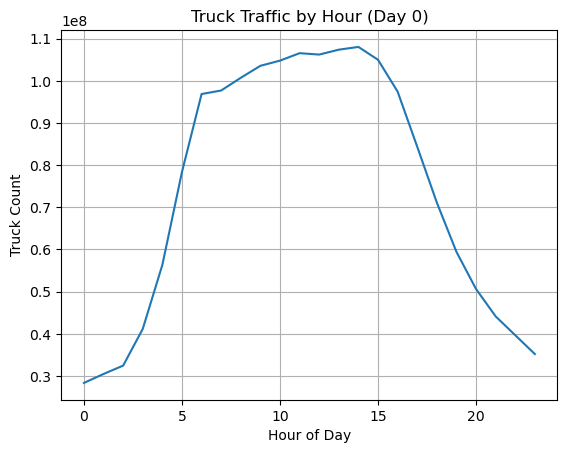

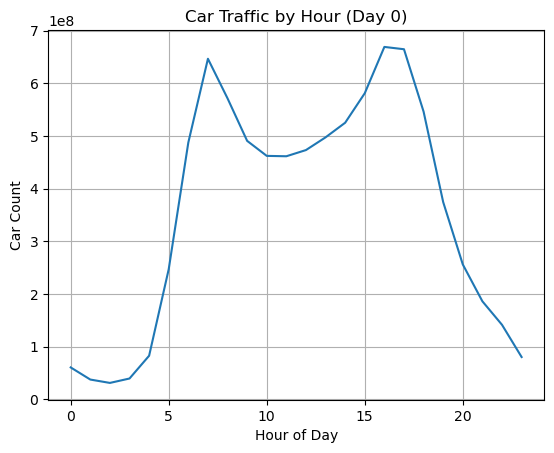

C:\Users\ffill\AppData\Local\Temp\ipykernel_21508\188030330.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ds=ds.resample('H').mean()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [7]:

# Transport data 
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\transport_data.csv",sep=',')
ds = ds[ds['country'].isin(countries)]
display(ds)
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data\emobility\Lkw__count", skiprows=2)

df_day0 = ds[ds["day"] == 0]
plt.plot(df_day0["hour"], df_day0["count"])
plt.xlabel("Hour of Day")
plt.ylabel("Truck Count")
plt.title("Truck Traffic by Hour (Day 0)")
plt.grid(True)
plt.show()

ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data\emobility\Pkw__count", skiprows=2)

df_day0 = ds[ds["day"] == 0]
plt.plot(df_day0["hour"], df_day0["count"])
plt.xlabel("Hour of Day")
plt.ylabel("Car Count")
plt.title("Car Traffic by Hour (Day 0)")
plt.grid(True)
plt.show()

ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\demand\transport_AB_s_55_2030.csv",sep=',')
ds.set_index('snapshot', inplace=True)
ds=ds.resample('H').mean()
ds['total'] = ds.sum(axis=1)

ds[['total']].plot(figsize=(12, 5), linewidth=1.5)
plt.title("Total Transport Demand – ASEAN Regions (2030 Scenario)")
plt.xlabel("Timestamp")
plt.ylabel("Total Transport Demand (MWh or MW)")  # Adjust unit based on source
plt.grid(True)
plt.tight_layout()
plt.show()

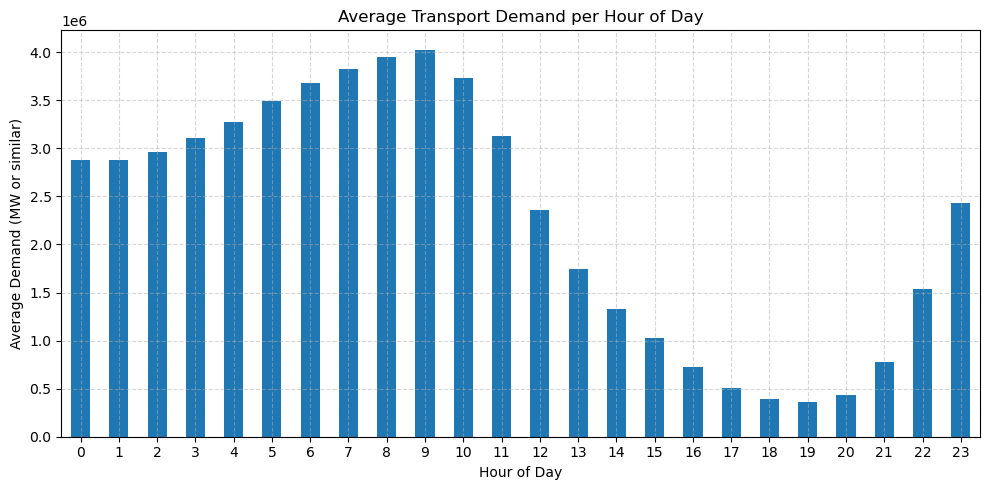

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and process your CSV
ds = pd.read_csv(
    r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\demand\transport_AB_s_55_2030.csv",
    sep=','
)

# Convert snapshot column to datetime
ds['snapshot'] = pd.to_datetime(ds['snapshot'])
ds.set_index('snapshot', inplace=True)

# OPTIONAL: drop non-numeric columns if needed
# ds = ds.select_dtypes(include='number')

# Calculate total across all demand columns
ds['total'] = ds.sum(axis=1)

# Group by hour of day (0 to 23) and calculate the mean
hourly_mean = ds.groupby(ds.index.hour)['total'].mean()

# Plot
hourly_mean.plot(kind='bar', figsize=(10, 5), linewidth=1.5)
plt.title("Average Transport Demand per Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW or similar)")
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [11]:
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\energy_totals_base.csv",sep=',')
ds = ds[ds["Unnamed: 0.1"].isin(countries)]
display(ds)
ds.columns

,Unnamed: 0.1,Unnamed: 0,agriculture biomass,agriculture electricity,agriculture oil,electricity rail,electricity residential,residential biomass,residential gas,residential heat biomass,...,other electricity,other oil,other biomass,other gas,other heat,non energy electricity,non energy oil,non energy biomass,non energy gas,non energy heat
0,PH,NaN,0.0461,2.7900,2.8012,0.1062,30.5520,59.4536,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0380,9.9211,0.0,0.0000,0.0
1,TH,NaN,0.0000,0.4680,34.9603,0.2150,49.2020,31.4891,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,221.4579,0.0,53.7731,0.0
2,MM,NaN,0.0000,0.0000,16.0165,0.0000,8.0758,55.9500,0.0000,NaN,...,0.0000,0.3808,0.0,0.0000,0.0,0.0000,3.9765,0.0,1.9186,0.0
3,BN,NaN,NaN,NaN,NaN,NaN,1.3287,0.0296,0.2333,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,1.5273,0.0,6.0653,0.0
4,KH,NaN,0.0000,0.0000,0.0036,0.0000,3.3996,7.9612,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,0.1545,0.0,0.0000,0.0
5,VN,NaN,4.4005,6.5954,10.9716,NaN,85.2952,2.7928,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,7.7632,0.0,8.3039,0.0
6,MY,NaN,0.0000,0.6639,10.2298,0.4778,31.5702,5.7866,0.0078,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,32.8993,0.0,139.8046,0.0
7,SG,NaN,NaN,NaN,NaN,3.0193,7.6813,0.0000,0.7359,NaN,...,0.0000,0.0000,0.0,0.0415,0.0,0.0000,78.4750,0.0,0.0000,0.0
8,ID,NaN,0.0000,0.5940,4.3145,0.2780,104.7140,85.6952,0.2417,NaN,...,NaN,NaN,NaN,NaN,NaN,4.4999,26.2596,0.0,79.8011,0.0
9,LA,NaN,0.0000,0.0419,0.3821,NaN,2.1358,9.8660,0.0000,NaN,...,0.9722,0.0000,0.0,0.0000,0.0,0.0000,0.0212,0.0,0.0000,0.0


Index(['Unnamed: 0.1', 'Unnamed: 0', 'agriculture biomass',
       'agriculture electricity', 'agriculture oil', 'electricity rail',
       'electricity residential', 'residential biomass', 'residential gas',
       'residential heat biomass', 'residential heat gas',
       'residential heat oil', 'residential oil', 'services biomass',
       'services electricity', 'services gas', 'services oil',
       'total domestic aviation', 'total domestic navigation',
       'total international aviation', 'total international navigation',
       'total rail', 'total residential space', 'total residential water',
       'total road', 'total services space', 'total services water',
       'electricity residential space', 'electricity residential water',
       'district heat share', 'electricity services space',
       'electricity services water', 'road electricity', 'road gas',
       'road biomass', 'road oil', 'agriculture coal', 'other electricity',
       'other oil', 'other biomass', 'oth

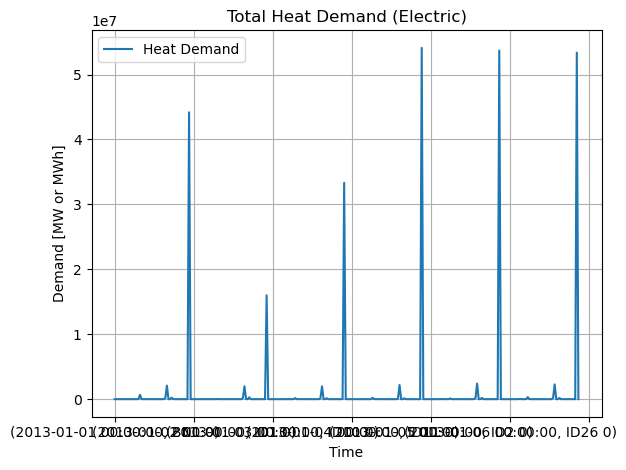

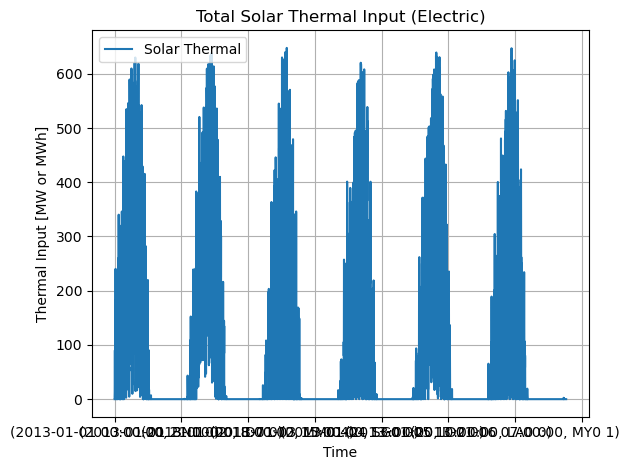

,Unnamed: 0,residential space weekday,residential space weekend,services space weekday,services space weekend,residential water weekday,residential water weekend,services water weekday,services water weekend
0,0,0.543784,0.539185,0.740230,0.791817,1.0,1.0,1.0,1.0
1,1,0.569050,0.564153,0.764203,0.792963,1.0,1.0,1.0,1.0
2,2,0.562402,0.557549,0.826442,0.896160,1.0,1.0,1.0,1.0
3,3,0.612035,0.607459,0.933848,1.066548,1.0,1.0,1.0,1.0
4,4,0.821009,0.818845,1.128809,1.277927,1.0,1.0,1.0,1.0


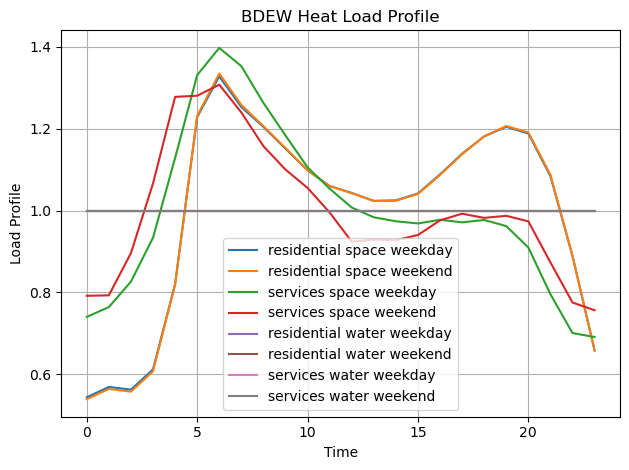

In [12]:
# Heat demand 
heat_demand_path = r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\demand\heat\heat_demand_total_elec_s_52_2030.nc"
ds_heat = xr.open_dataset(heat_demand_path)
ds_heat_total = ds_heat.to_dataframe().sum(axis=1)
ds_heat_total.plot(label='Heat Demand')
plt.title("Total Heat Demand (Electric)")
plt.xlabel("Time")
plt.ylabel("Demand [MW or MWh]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --- 2. Open and plot NetCDF: solar_thermal_total_elec_s_50_2030.nc ---
solar_path = r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\demand\heat\solar_thermal_total_elec_s_50_2030.nc"
ds_solar = xr.open_dataset(solar_path)

# Plot total solar thermal potential or input
ds_solar_total = ds_solar.to_dataframe().sum(axis=1)
ds_solar_total.plot(label='Solar Thermal')
plt.title("Total Solar Thermal Input (Electric)")
plt.xlabel("Time")
plt.ylabel("Thermal Input [MW or MWh]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --- 3. Open and plot CSV: heat_load_profile_BDEW.csv ---
csv_path = r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data\heat_load_profile_BDEW.csv"
df_bdew = pd.read_csv(csv_path)
display(df_bdew.head())

# If the first column is time and rest are demand profiles:
df_bdew.set_index(df_bdew.columns[0], inplace=True)
df_bdew.plot(title="BDEW Heat Load Profile")
plt.xlabel("Time")
plt.ylabel("Load Profile")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/industrial_database.csv",sep=',')
display(ds[ds['country'].isin(countries)])
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\demand/base_industry_totals_2030_AB.csv",sep=',')
display(ds[ds['country'].isin(countries)])


In [ ]:
#costs
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\costs_2030.csv",sep=',')
display(ds)